In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"titanic.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [6]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


## 1단계. 데이터 전처리

In [19]:
# 수치형: Age, SibSp, Parch, Fare
# 분류형: Survived, Pclass, Sex
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


In [20]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.544332,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.013778,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


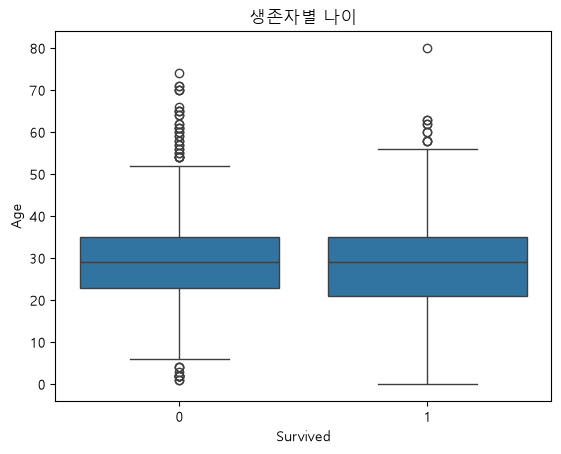

In [21]:
# 생존자별 나이
sns.boxplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")
plt.show()

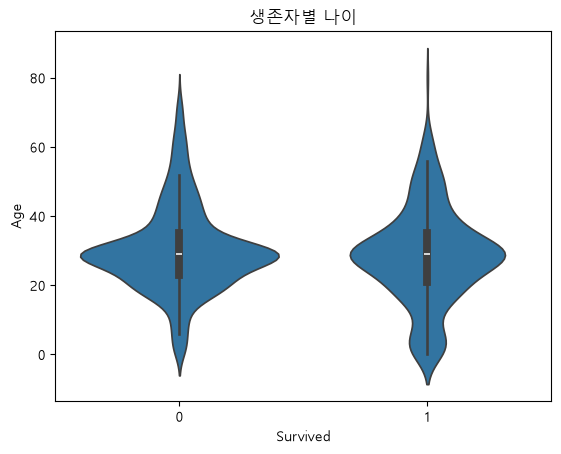

In [22]:
# 생존자별 나이
sns.violinplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")
plt.show()

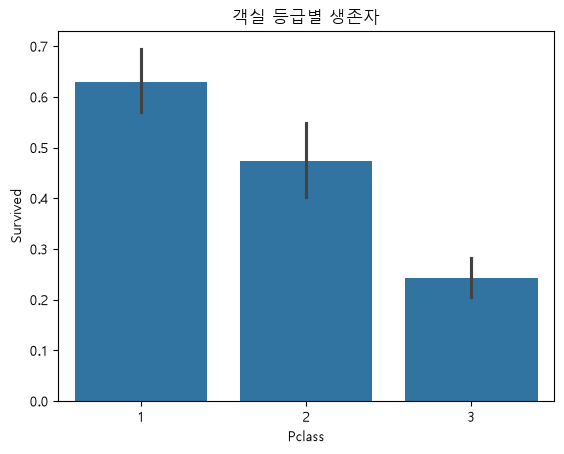

In [23]:
sns.barplot(titanic_df, x="Pclass", y="Survived")
plt.title("객실 등급별 생존자")
plt.show()

In [24]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [25]:
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


### 원 핫 인코딩(One-Hot encoding)
- 글자나 범주형(분류형) 데이터를 컴퓨터가 이해하기 쉬운 0과 1의 행렬구조로 변환하는 전처리 기술이다.

In [26]:
# 분류형 인코딩 : 바나나=0, 사과=1, 멜론=2
# 원-핫-인코딩 : 바나나=001, 사과=010, 멜론=100(첫번째 자리는 바나나, 두번째는 사과, 세번째는 멜론을 의미)

In [28]:
# titanic_df["Sex"].map(lambda gender: {"male":0, "female":1}[gender])
titanic_df["Sex"] = titanic_df["Sex"].map({"male":0, "female":1})

In [30]:
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250


## 파생변수

In [31]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1


### ※ 상관관계 분석 및 다중공선성

In [33]:
corr_matrix = titanic_df.corr(numeric_only=True)

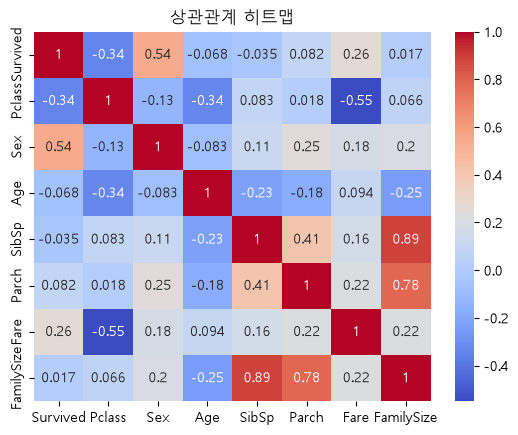

In [37]:
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [38]:
# 다중공선성 : 구분되어있긴 하지만 그 상관관계가 거의 1에 가까운 컬럼들이 존재 = 다중공선성의 발생 
# ex) 시우 | 지혁 | 준승 | 준승(카톡) | 준승(문자)

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [41]:
X = titanic_df.drop("Survived", axis=1)
X.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,3,0,22,1,0,7.2500,2
1,1,1,38,1,0,71.2833,2
2,3,1,26,0,0,7.9250,1


In [42]:
y = titanic_df["Survived"]
y.head(3)

0    0
1    1
2    1
Name: Survived, dtype: int64

In [43]:
X.shape

(891, 7)

In [60]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif
# index 3,4,6에 다중공선성이 발생 -> 오류

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


[np.float64(1.6743819682616452),
 np.float64(1.0794219842460373),
 np.float64(1.2065529011311142),
 np.float64(1.589318305130038),
 np.float64(1.1915806348327602)]

### VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.
  즉 독립변수와 독립변수와의 관계를 의미하며 다른 변수들과의 조합을 수치로 표현한 것이다.

### VIF 해석
- VIF < 5: 문제 없음
- 5 <= VIF <= 10: 주의
- 10 < 10: 다중 공선성 의심(조치, 삭제, 고려)

In [48]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)

In [49]:
titanic_df

,Survived,Pclass,Sex,Age,Fare,FamilySize
0,0,3,0,22,7.2500,2
1,1,1,1,38,71.2833,2
2,1,3,1,26,7.9250,1
3,1,1,1,35,53.1000,2
4,0,3,0,35,8.0500,1
...,...,...,...,...,...,...
886,0,2,0,27,13.0000,1
887,1,1,1,19,30.0000,1
888,0,3,1,29,23.4500,4
889,1,1,0,26,30.0000,1


In [50]:
X = titanic_df.drop("Survived", axis=1)
X.head()

,Pclass,Sex,Age,Fare,FamilySize
0,3,0,22,7.2500,2
1,1,1,38,71.2833,2
2,3,1,26,7.9250,1
3,1,1,35,53.1000,2
4,3,0,35,8.0500,1


In [51]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [66]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


[np.float64(1.6743819682616452),
 np.float64(1.0794219842460373),
 np.float64(1.2065529011311142),
 np.float64(1.589318305130038),
 np.float64(1.1915806348327602)]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [68]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 5) (179, 5) (712,) (179,)


In [69]:
scaler = StandardScaler()

In [70]:
# 표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계. 모델 준비

In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
lr = LogisticRegression()

## 3단계. 모델 학습

In [75]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 4단계. 모델 평가

In [76]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(f"훈련 데이터 정확도 점수: {train_score:.2f}")
print(f"테스트 데이터 정확도 점수: {test_score:.2f}")

훈련 데이터 정확도 점수: 0.81
테스트 데이터 정확도 점수: 0.78


### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [79]:
y_pred = lr.predict(X_test_scaled)

In [81]:
print(f"모델의 예측 확률: {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값: {y_pred[:5]}")
print(f"모델의 정답: {y_test.values[:5]}")

lr.predict_proba(X_test_scaled)

모델의 예측 확률: [[0.88867611 0.11132389]
 [0.95189906 0.04810094]
 [0.04468729 0.95531271]
 [0.88506978 0.11493022]
 [0.90039734 0.09960266]]
모델의 예측 값: [0 0 1 0 0]
모델의 정답: [0 0 1 0 0]


array([[0.88867611, 0.11132389],
       [0.95189906, 0.04810094],
       [0.04468729, 0.95531271],
       [0.88506978, 0.11493022],
       [0.90039734, 0.09960266],
       [0.93273411, 0.06726589],
       [0.0491955 , 0.9508045 ],
       [0.27294405, 0.72705595],
       [0.78429348, 0.21570652],
       [0.46392437, 0.53607563],
       [0.88195462, 0.11804538],
       [0.87193025, 0.12806975],
       [0.90348   , 0.09652   ],
       [0.46557148, 0.53442852],
       [0.9031684 , 0.0968316 ],
       [0.71963386, 0.28036614],
       [0.913187  , 0.086813  ],
       [0.06826082, 0.93173918],
       [0.07195335, 0.92804665],
       [0.89085431, 0.10914569],
       [0.94949704, 0.05050296],
       [0.86772812, 0.13227188],
       [0.78613711, 0.21386289],
       [0.90331112, 0.09668888],
       [0.87201938, 0.12798062],
       [0.49138217, 0.50861783],
       [0.89245566, 0.10754434],
       [0.62026443, 0.37973557],
       [0.87653596, 0.12346404],
       [0.90327201, 0.09672799],
       [0.

In [82]:
print(f"테스트 정확도: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

테스트 정확도: 0.8061797752808989
테스트 정확도: 0.7821229050279329


## ROC-Curve
- 이진 분류 모델의 성능을 임계값을 기준엣 시각적으로 평가한 그래프이다.
- x축(특이도) - TPR: 실제 양성인데 모델이 양성이라 예측한 비율
- y축(민감도) - FPR: 실제 음성인데 모델이 양성이라 예측한 비율

In [83]:
from sklearn.metrics import RocCurveDisplay

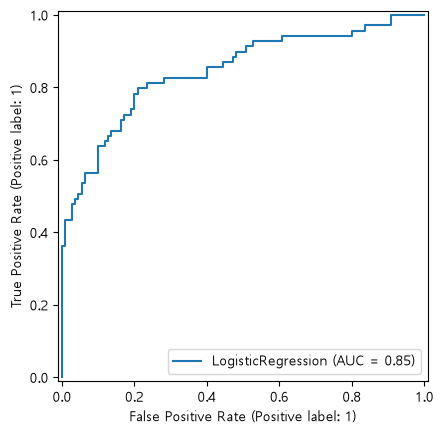

In [84]:
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [86]:
# 각 가중치
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef",ascending=False)
lr.coef_[0]

array([-0.90987823,  1.3345076 , -0.50931766,  0.15320702, -0.31641659])

In [87]:
coef_df

,Features,Coef
1,Sex,1.334508
3,Fare,0.153207
4,FamilySize,-0.316417
2,Age,-0.509318
0,Pclass,-0.909878


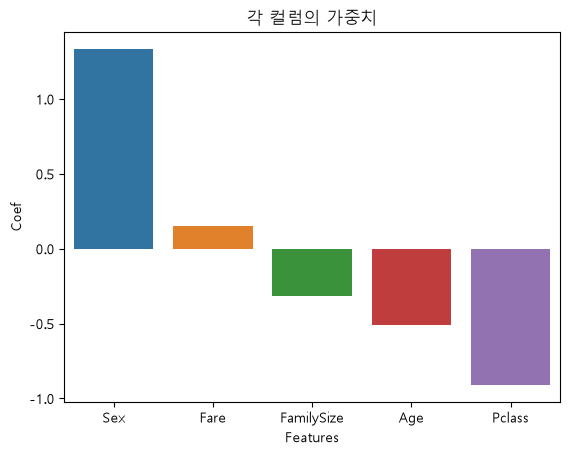

In [88]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

"""
    성별(Sex)은 양의 상관관계 가진다. 즉 성별이 1(female)일수록 생존확률 높다(1).
    객실 등급(Pclass)는 음의 상관관계를 가진다. 즉 객실 등급이 높을수록(숫자가 작을 수록) 생존확률이 높다(1).
"""
None

In [90]:
wrong_cases = X_test[y_test != y_pred]
wrong_cases.head()

,Pclass,Sex,Age,Fare,FamilySize
400,3,0,39,7.9250,1
593,3,1,29,7.7500,3
630,1,0,80,30.0000,1
569,3,0,32,7.8542,1
271,3,0,25,0.0000,1


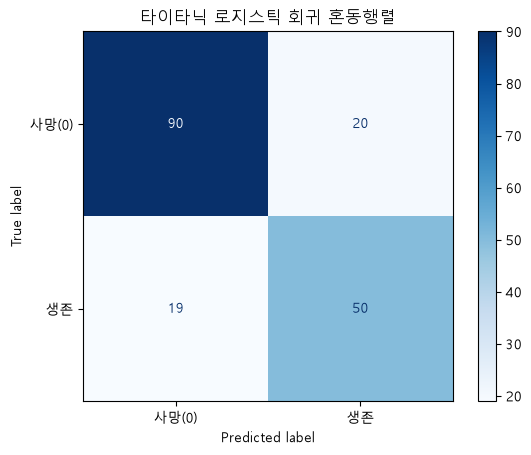

In [92]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    display_labels=["사망(0)","생존"],
    cmap="Blues"
)

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()

In [94]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       109
           1       0.72      0.71      0.72        70

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [95]:
# 커져버린~ 내마으음과~ 자꾸만~ 새어나가/아\아
# 한번만 더어어어어 그대르흘 
# 안아볼 혀어어 했지마ㅏ안